In [119]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import Functions as myfun
from scipy.stats import pearsonr
from scipy.cluster import hierarchy
import random

In [120]:
YourFolder = "A1AT"

In [121]:
#Load Data
train_lp = pd.read_excel('../Data/'+YourFolder+'/sim_CHOlp_trainx.xlsx',index_col=0)
test_lp = pd.read_excel('../Data/'+YourFolder+'/NEWlp_testx.xlsx',index_col=0)
train_gp = pd.read_excel('../Data/'+YourFolder+'/CHOgp_trainy.xlsx',index_col=0)
test_gp = pd.read_excel('../Data/'+YourFolder+'/NEWgp_testy.xlsx',index_col=0)

In [122]:
test_gp.shape

(74, 6)

In [12]:
all_glycan_new = train_gp.index


In [7]:
#Load motif names
Bojar_motif_file = pd.read_excel("../Data/Motifs_name.xlsx",index_col=0)
#Extract only the N glycan motifs
Nglycan_motifs = Bojar_motif_file.index[Bojar_motif_file['Glycan type']=="N"]
#We use the LinearCode format
motif_linearcode = np.array(Bojar_motif_file.loc[Nglycan_motifs,'LinearCode'])
len(motif_linearcode)

32

In [10]:
#Load lectins bojar rules for N glycans -> binding rule matrix
bojar_rule = pd.read_excel("../Data/Lectin binding rules z-scores.xlsx",index_col=0)
bojar_rule_N = bojar_rule[Nglycan_motifs] #Get N-glycofeatures only
bojar_rule_N=bojar_rule_N.sort_index()
#The lectins that we used, make sure the order of lectins are same as the measured_lp
Bojar_8Lectin_Names = ['DSL_Vector','LCA_Vector','MAL-I_Vector','PHA-E_Vector'
                       ,'PHA-L_Vector','RCAI_Vector','SNA_Vector','WGA_Vector']

measured_lp = pd.read_excel('../Data/Experimental ELISA data.xlsx',index_col=0)
measured_lp.sort_index(inplace=True)

bojar_8rule_N = bojar_rule_N.loc[Bojar_8Lectin_Names]
bojar_8rule_N.index = measured_lp.index #Align index names
bojar_8rule_N.shape

bojar_rule_z95= bojar_8rule_N.copy() # Keep p values >= 0.05
bojar_rule_z95[bojar_rule_z95<1.645] = 0

In [13]:
#Get the glycan-features df
binary_count =False
lm = myfun.get_motif_counts(all_glycan_new,motif_linearcode,binary_count)
lm.columns=Nglycan_motifs
lm.columns.name=None
# lm

In [16]:
reg_rule = pd.read_excel('../Data/'+YourFolder+'/reg_rule.xlsx',index_col=0)

In [20]:
#modify lm so that when ploting the heat map, we can cluster the glycans as well.
lm_plot = lm.copy()
lm_plot = lm_plot[lm_plot.columns[lm_plot.sum(0) != 0]]
lm_plot['high mannose'] = lm_plot['Man5']+lm_plot['Man6']+lm_plot['Man 8']+lm_plot['Man 9']+lm_plot['Man7 ']
lm_plot['LacNAc'] = lm_plot['Type II poly-LacNAc']+lm_plot['Internal Type II LacNAc']+lm_plot['terminal Type II LacNAc']
lm_plot['Triantennary'] = lm_plot['Tri-antennary N: b1,6']+lm_plot['Tri-antennary : b1,4']
lm_plot['Term. Mannose'] = lm_plot['Terminal Man1-2']+lm_plot['Terminal Man1-6']
lm_plot['Term. Sialic acid'] = lm_plot['Terminal 2,3 NeuAc']+lm_plot['Terminal 2,6 NeuAc']
lm_plot.drop(['Man6','Man 8','Man5','Man 9','Man7 ','Type II poly-LacNAc','Internal Type II LacNAc',
              'terminal Type II LacNAc','Tri-antennary N: b1,6','Tri-antennary : b1,4',
              'Terminal Man1-2','Terminal Man1-6','Terminal 2,6 NeuAc','Terminal 2,3 NeuAc'],axis=1,inplace=True)
lm_plot.drop(['Triantennary','Biantennary','Tetraantennary','high mannose'],axis=1,inplace=True)
(lm_plot.sum(1) == 0).any() #False
lm_plot=lm_plot.applymap(lambda x: 1 if x != 0 else 0)
print(lm_plot.sum())
print(lm_plot.sum(1))

Terminal GlcNAcb     17
Terminal b-Gal       31
Core Fucose          34
LacNAc               56
Term. Mannose        19
Term. Sialic acid    40
dtype: int64
Ma6(Ma3)Mb4GNb4GN                                                                       1
Ma6(Ma2Ma3)Mb4GNb4GN                                                                    1
Ma6(GNb2Ma3)Mb4GNb4GN                                                                   2
Ma6(Ma3)Mb4GNb4(Fa6)GN                                                                  2
Ma6(Ab4GNb2Ma3)Mb4GNb4GN                                                                3
                                                                                       ..
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN               4
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN           3
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN         2
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2

/var/folders/7r/qls2yr0s01bg15zgs1w2msg00000gn/T/ipykernel_89209/2844320885.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lm_plot=lm_plot.applymap(lambda x: 1 if x != 0 else 0)


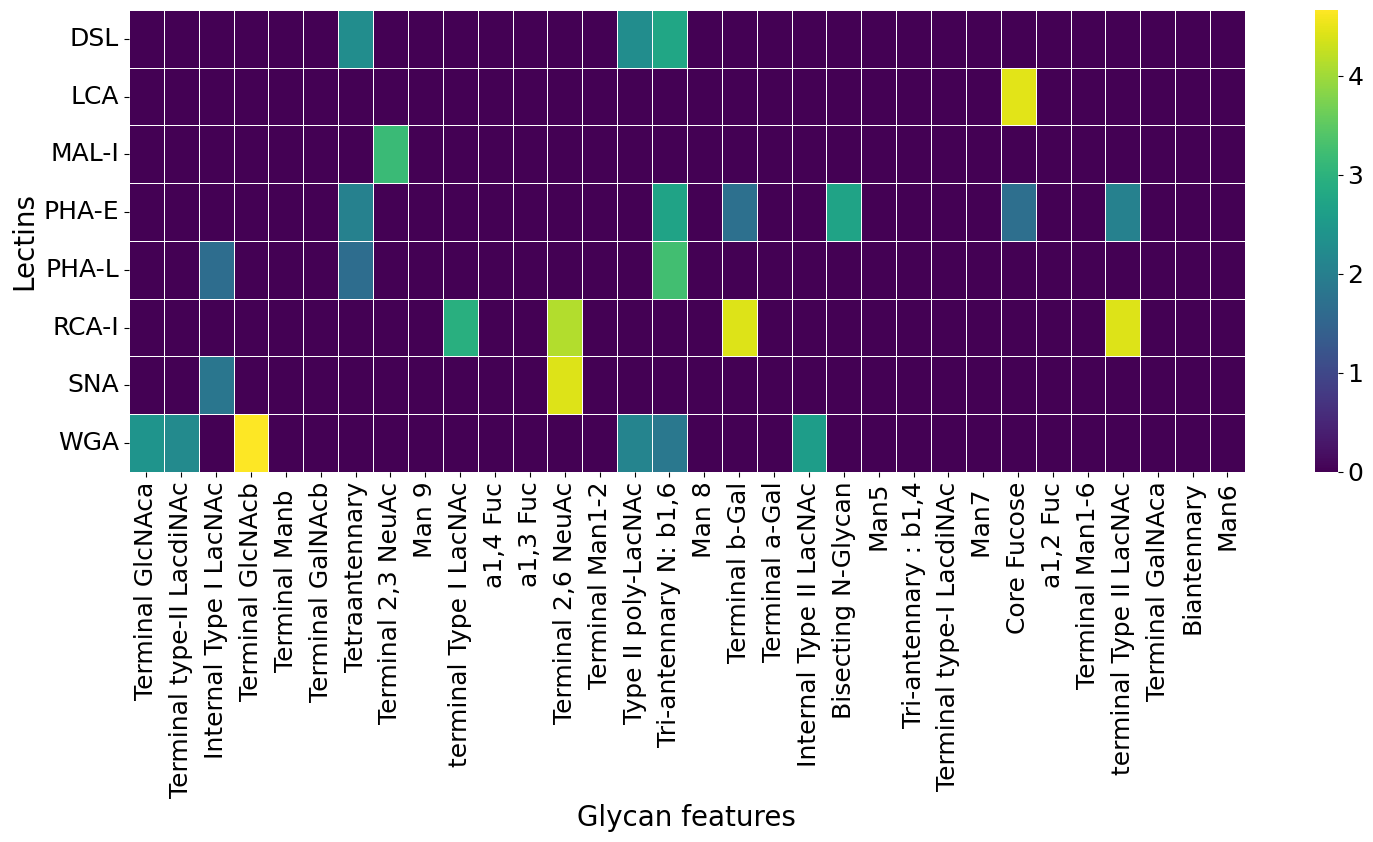

In [112]:
bojar_rule_z95
plt.figure(figsize=(18, 6)) # Adjust figure size as needed
sns.heatmap(bojar_rule_z95, cmap='viridis', fmt=".2f", linewidths=.5)
plt.xlabel('Glycan features')
plt.ylabel('Lectins')
plt.show()

In [22]:
pd.set_option('display.max_rows', None)
sorted_data = lm_plot.sort_values(by=['LacNAc', 'Term. Sialic acid','Terminal b-Gal','Core Fucose','Term. Mannose','Terminal GlcNAcb'], 
                                  ascending=[False,False,False,False,True,True])
# sorted_data

In [23]:
#Use dirichlet distribution to simulate
starter=[1]*73
starter = np.array([[s/ sum(starter) for s in starter]])
sim_gp_arr = []
sim_lp_arr = []
i = 0
total_run=0
seed=1
model_lp = None
while i < 100:
    total_run+=1
    np.random.seed(seed)
    seed+=1
    alpha =0.9
    sim_gp = np.array([np.random.dirichlet((row/row.sum())**alpha) for row in starter])[0]
    sim_gp[sim_gp<0.01] = 0
    sim_gp*=(1/sim_gp.sum())
    # correlation = np.corrcoef(starter, FetB_data_varied)[0, 1]
    sim_lp_raw = myfun.simulate_lp(lm,bojar_rule_z95,sim_gp,False)
    sim_lp = myfun.fit_sim_lp_reg_rules(sim_lp_raw, reg_rule)
    sim_lp*=(1/sim_lp.sum())
    # glycan_lec = glycan_motif.dot(bojar_rule_z95.T)
    # lp = (glycan_lec.T).dot(gp)
    if model_lp is None:
        model_lp = sim_lp
        sim_lp_arr.append(model_lp)
    else:
        corr = abs(pearsonr(model_lp,sim_lp)[0])
        if corr>0.95:
            sim_gp_arr.append(sim_gp)
            sim_lp_arr.append(sim_lp)
            i+=1
print('100 out of '+str(total_run)+' simulated glycoprofiles have very similar lectin profile.')      


sim_gp_df = pd.DataFrame(np.array(sim_gp_arr).T,index=train_gp.index)
sim_gp_df.index.name=None
sim_gp_df.columns = [str(i) for i in range(1,len(sim_gp_df.columns)+1)]
sim_gp_df = myfun.normalize(sim_gp_df,0.02)
sim_lp_df = pd.DataFrame(np.array(sim_lp_arr).T,index=train_lp.index)
sim_lp_df.index.name=None
sim_lp_df.columns = [str(i) for i in range(1,len(sim_lp_df.columns)+1)]

###Note: uncomment below to save
sim_gp_df.to_excel('../Data/'+YourFolder+'/sim_gp_motivation.xlsx',index = True)
sim_gp_df = sim_gp_df.loc[sorted_data.index]

100 out of 4722 simulated glycoprofiles have very similar lectin profile.


In [24]:
# get row_color for the glycans.
glycan_color=['#BC3C29', '#0072B5', '#E18727','#20854E','#7876B1','#6F99AD','#FFDC91','#EE4C97']

LacNAc_color = ['white','#0072B5']
lut1=dict(zip([0,1],LacNAc_color))
row_colors1 = sorted_data['LacNAc'].map(lut1)

T_SA_color = ['white','#E18727']
lut2=dict(zip([0,1],T_SA_color))
row_colors2 = sorted_data['Term. Sialic acid'].map(lut2)

C_Fuc_color = ['white','#7876B1']
lut3=dict(zip([0,1],C_Fuc_color))
row_colors3 = sorted_data['Core Fucose'].map(lut3)

T_Gal_color = ['white','#20854E']
lut4=dict(zip([0,1],T_Gal_color))
row_colors4 = sorted_data['Terminal b-Gal'].map(lut4)

T_GN_color = ['white','#6F99AD']
lut5=dict(zip([0,1],T_GN_color))
row_colors5 = sorted_data['Terminal GlcNAcb'].map(lut5)

T_Man_color = ['white','#FFDC91']
lut6=dict(zip([0,1],T_Man_color))
row_colors6 = sorted_data['Term. Mannose'].map(lut6)

col_colors = pd.concat([row_colors1,row_colors2,row_colors4,row_colors3,row_colors5,row_colors6],axis=1)

/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


<Figure size 800x1000 with 0 Axes>

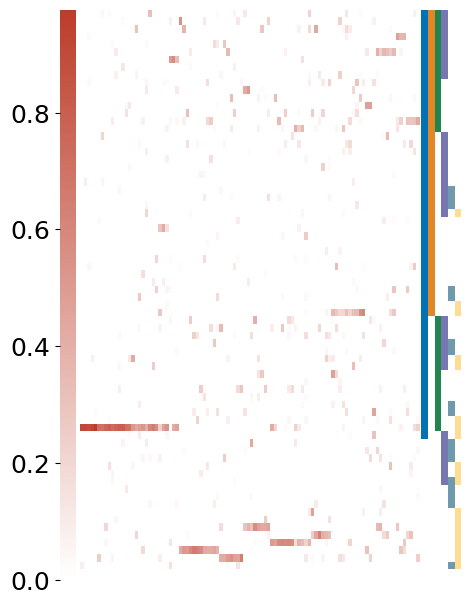

In [25]:
# Create a custom colormap with blue at the lower end and red at the upper end
colors = ["white", "#BC3C29"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(8,10))
# sns.heatmap(sim_gp_df.T, annot=False, cmap=cmap, linewidths=0, linecolor='none')
# plt.title('Heatmap of DataFrame without y-axis ticks')
g = sns.clustermap(sim_gp_df, cmap=cmap, row_colors=col_colors,linewidths=0, figsize=(8, 10), method='complete', row_cluster=False)

g.ax_heatmap.set_xticks([])   # Remove y-axis ticks
g.ax_heatmap.set_yticks([]) 
g.ax_col_dendrogram.set_visible(False) #remove the dendrogram label
g.ax_row_dendrogram.set_visible(False) #remove the dendrogram label

#adjust the legend color bar 
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.45, 0.1, 0.02, 0.57])
g.ax_cbar.tick_params(left=True,right=False,labelleft=True,labelright=False)

#adjust the col_color position
ax_col_colors = g.ax_row_colors
box = ax_col_colors.get_position()
# box_heatmap = g.ax_heatmap.get_position()
ax_col_colors.set_position([box.x0+0.595, box.y0, 0.05, box.height])
ax_col_colors.set_xticklabels([])
ax_col_colors.xaxis.set_tick_params(size=0) #remove the tick marks (- sign) 
plt.show()

/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


<Figure size 800x1000 with 0 Axes>

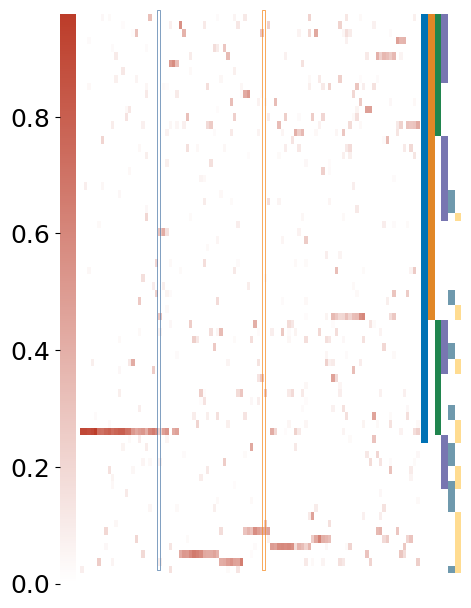

In [99]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# --- your existing code (abridged just for context) ---
colors = ["white", "#BC3C29"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(8,10))
g = sns.clustermap(
    sim_gp_df, cmap=cmap, row_colors=col_colors, linewidths=0,
    figsize=(8, 10), method='complete', row_cluster=False
)

g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_yticks([])
g.ax_col_dendrogram.set_visible(False)
g.ax_row_dendrogram.set_visible(False)

# adjust colorbar
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.45, 0.1, 0.02, 0.57])
g.ax_cbar.tick_params(left=True, right=False, labelleft=True, labelright=False)

# adjust row_colors position
ax_col_colors = g.ax_row_colors
box = ax_col_colors.get_position()
ax_col_colors.set_position([box.x0 + 0.595, box.y0, 0.05, box.height])
ax_col_colors.set_xticklabels([])
ax_col_colors.xaxis.set_tick_params(size=0)

# --- NEW: highlight chosen glycoprofile columns by drawing boxes ---
def highlight_columns_on_clustermap(g, col_labels, colors, linewidth=2.5):
    """
    Draw a rectangle over specified columns on a seaborn clustermap heatmap.

    Parameters
    ----------
    g : sns.matrix.ClusterGrid
        Result returned by seaborn.clustermap
    col_labels : list
        Column labels to highlight (must match g.data.columns after clustering).
        You can pass integers like 24, 55 if your column labels are "1","2",...
    colors : list
        Edge colors for the boxes (same length as col_labels)
    linewidth : float
        Width of the rectangle edges
    """
    # Columns after clustering:
    clustered_cols = list(g.data.columns)
    n_rows = g.data.shape[0]

    for lab, col in zip(col_labels, colors):
        # If your sim_gp_df uses "1","2",... as strings, coerce ints to str
        lab = str(lab)
        if lab not in clustered_cols:
            raise ValueError(f"Column '{lab}' not found in clustered columns.")
        j = clustered_cols.index(lab)  # column position in the clustered order

        # Rectangle spans full height of heatmap and 1 column width
        rect = Rectangle(
            (j - 0.5, -0.5),  # (x,y) lower-left in data coords
            width=1, height=n_rows,
            fill=False, edgecolor=col, linewidth=linewidth,
            clip_on=False, zorder=5
        )
        g.ax_heatmap.add_patch(rect)

# Example: highlight columns 24 and 55 with blue and yellow boxes
highlight_columns_on_clustermap(
    g,
    col_labels=[24, 55],                   # your chosen glycoprofile indices
    colors=["#4C78A8", "#F58518"],         # blue, yellow
    linewidth=0.5
)

plt.show()


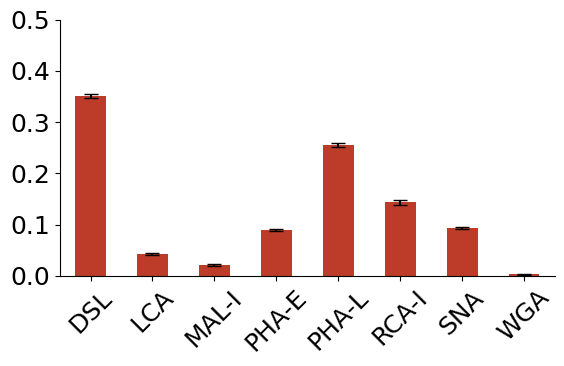

In [100]:
#Plot the lp of the grouped gp

LPs_0_df = sim_lp_df.T
means = LPs_0_df.mean()
errors = LPs_0_df.sem()

plt.figure(figsize=(6, 4))
ax = means.plot(kind='bar', yerr=errors, capsize=5,rot=45,color=['#BC3C29'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import pandas as pd

# ---- Inputs ----
# sim_gp_df: rows = glycans, columns = simulated glycoprofiles you retained
# (assumed already nonnegative and column-normalized, but the code is robust if not)

def _top_k_pairs_from_matrix(D, names, k=1):
    """Return top-k pairs with largest distances from a symmetric distance matrix D."""
    iu = np.triu_indices(D.shape[0], k=1)
    vals = D[iu]
    order = np.argsort(vals)[::-1]  # largest first
    picks = order[:k]
    out = []
    for idx in picks:
        a, b = iu[0][idx], iu[1][idx]
        out.append((names[a], names[b], float(vals[idx])))
    return out

def most_distinct_pairs(sim_gp_df, k=1):
    X = sim_gp_df.values.astype(float)        # shape: G x N
    names = np.array(sim_gp_df.columns)

    # --- COSINE DISTANCE (1 - cosine similarity) ---
    col_norms = np.linalg.norm(X, axis=0)
    valid_cos = col_norms > 0
    Xc = X[:, valid_cos]
    names_c = names[valid_cos]
    U = Xc / col_norms[valid_cos]             # unit-length columns
    # cosine similarity matrix
    cos_sim = U.T @ U
    np.fill_diagonal(cos_sim, 1.0)            # similarity with self = 1
    cos_dist = 1.0 - cos_sim                  # distance = 1 - sim

    topk_cos = _top_k_pairs_from_matrix(cos_dist, names_c, k=k)

    # --- PEARSON DISTANCE (1 - Pearson r) ---
    # standardize columns (mean 0, unit std); drop constant columns
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=1)
    valid_pear = X_std > 0
    Z = (X[:, valid_pear] - X_mean[valid_pear]) / X_std[valid_pear]
    names_p = names[valid_pear]
    # correlation matrix
    n_feat = Z.shape[0]
    corr = (Z.T @ Z) / (n_feat - 1)
    np.fill_diagonal(corr, 1.0)
    pear_dist = 1.0 - corr

    topk_pear = _top_k_pairs_from_matrix(pear_dist, names_p, k=k)

    return {
        "cosine_distance_topk": topk_cos,   # list of (colA, colB, distance)
        "pearson_distance_topk": topk_pear  # list of (colA, colB, distance)
    }

# ---- Usage ----
res = most_distinct_pairs(sim_gp_df, k=3)  # change k as needed
print("Top-3 most distinct pairs by cosine distance:")
for a, b, d in res["cosine_distance_topk"]:
    print(f"{a} vs {b}: cosine distance = {d:.4f}")

print("\nTop-3 most distinct pairs by Pearson distance:")
for a, b, d in res["pearson_distance_topk"]:
    print(f"{a} vs {b}: 1 - Pearson r = {d:.4f}")

# If you want the single most distinct pair for overlay/plotting:
(a_cos, b_cos, d_cos) = res["cosine_distance_topk"][0]
gp_a_cos = sim_gp_df[a_cos]
gp_b_cos = sim_gp_df[b_cos]

(a_pear, b_pear, d_pear) = res["pearson_distance_topk"][0]
gp_a_pear = sim_gp_df[a_pear]
gp_b_pear = sim_gp_df[b_pear]


Top-3 most distinct pairs by cosine distance:
99 vs 100: cosine distance = 1.0000
25 vs 75: cosine distance = 1.0000
25 vs 93: cosine distance = 1.0000

Top-3 most distinct pairs by Pearson distance:
19 vs 50: 1 - Pearson r = 1.0794
24 vs 55: 1 - Pearson r = 1.0784
24 vs 44: 1 - Pearson r = 1.0772


In [60]:
import numpy as np
import matplotlib.pyplot as plt

def plot_glyco_separate_bars(sim_gp_df, idx1, idx2,
                             color1="#4C78A8", color2="#F58518",
                             sort_by_diff=True, top_n=None,
                             zero_policy="both",  # "both" (drop gp1==0 & gp2==0) or "any" (drop if either is 0)
                             xtick_rotation=90, figsize=(12, 7), save_path=None):
    """
    Plot two glycoprofiles as separate bar plots with different colors.

    Parameters
    ----------
    sim_gp_df : DataFrame (rows=glycans, cols=profiles labeled "1","2",...)
    idx1, idx2 : int|str  Column indices to plot (e.g., 3, 57)
    color1, color2 : str  Colors for the two bar plots
    sort_by_diff : bool   Sort glycans by |gp1 - gp2| descending
    top_n : int|None      Show only top-N glycans by |Δ|
    zero_policy : {"both","any"}
        "both": drop glycans where gp1==0 AND gp2==0 (keeps informative zeros)
        "any" : drop glycans where gp1==0 OR gp2==0
    """

    col1, col2 = str(idx1), str(idx2)
    if col1 not in sim_gp_df.columns or col2 not in sim_gp_df.columns:
        raise ValueError(f"Columns '{col1}' or '{col2}' not found in sim_gp_df.")

    gp1 = sim_gp_df[col1].astype(float).copy()
    gp2 = sim_gp_df[col2].astype(float).copy()

    # Exclude glycans by zero policy
    if zero_policy == "both":
        keep = ~((gp1 == 0) & (gp2 == 0))
    elif zero_policy == "any":
        keep = ~((gp1 == 0) | (gp2 == 0))
    else:
        raise ValueError("zero_policy must be 'both' or 'any'")
    gp1, gp2 = gp1[keep], gp2[keep]

    # Sort by |Δ|
    if sort_by_diff:
        order = (gp1 - gp2).abs().sort_values(ascending=False).index
        gp1, gp2 = gp1.loc[order], gp2.loc[order]

    # Optional top-N
    if top_n is not None:
        gp1, gp2 = gp1.iloc[:top_n], gp2.iloc[:top_n]

    names = gp1.index.to_list()
    x = np.arange(len(names))

    # Cosine distance (for title context)
    def _cosine_distance(a, b):
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return np.nan if na == 0 or nb == 0 else 1.0 - float(np.dot(a, b) / (na * nb))
    cos_d = _cosine_distance(gp1.values, gp2.values)

    fig, axes = plt.subplots(2, 1, figsize=figsize, constrained_layout=True)

    # Plot A
    axes[0].bar(x, gp1.values, color=color1)
    axes[0].set_title(f"Glycoprofile {col1}")
    axes[0].set_ylabel("Frac. of tot. abun.")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([])

    # Plot B
    axes[1].bar(x, gp2.values, color=color2)
    axes[1].set_title(f"Glycoprofile {col2}")
    axes[1].set_ylabel("Frac. of tot. abun.")
    axes[1].set_xlabel("Glycans")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=45, ha="right")

    # Figure-level title
    fig.suptitle(
        f"Glycoprofiles {col1} vs {col2} — separate bars | Cosine distance = {cos_d:.3f}"
        + (f" | top {len(names)} glycans" if top_n else ""),
        y=1.02, fontsize=12
    )

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


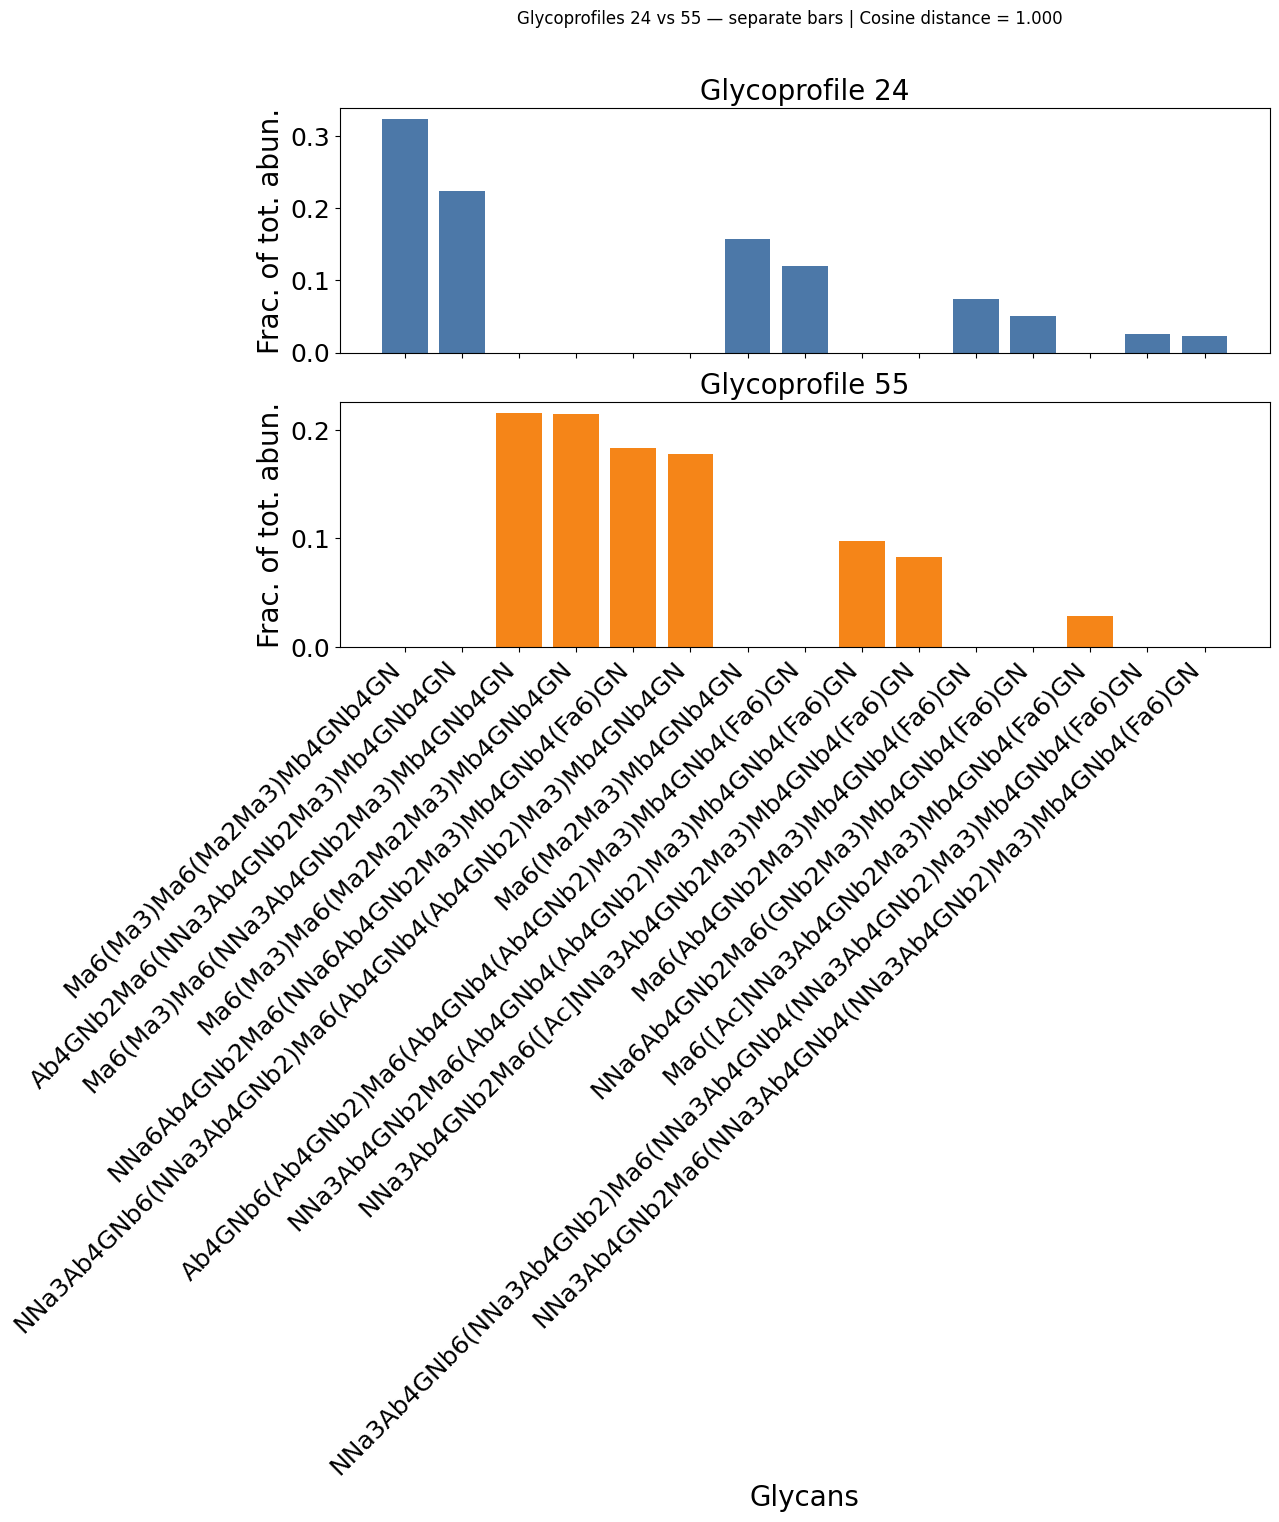

In [61]:
plot_glyco_separate_bars(sim_gp_df, 24, 55)

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

def plot_lectin_profiles_grouped(sim_lp_df, idx1, idx2,
                                 color1="#4C78A8", color2="#F58518",
                                 sort_by_diff=False, top_n=None,
                                 zero_policy="keep",   # "keep", "both", or "any"
                                 xtick_rotation=45, figsize=(8, 5),
                                 show_r_under_legend=True,
                                 r_text_fmt="Pearson r = {r:.3f}",
                                 r_text_pad_px=6,
                                 save_path=None):
    c1, c2 = str(idx1), str(idx2)
    if c1 not in sim_lp_df.columns or c2 not in sim_lp_df.columns:
        raise ValueError(f"Columns '{c1}' or '{c2}' not found in sim_lp_df.")

    lp1_full = sim_lp_df[c1].astype(float).copy()
    lp2_full = sim_lp_df[c2].astype(float).copy()

    # Pearson r on the full (pre-filter) vectors for context
    if lp1_full.std(ddof=1) == 0 or lp2_full.std(ddof=1) == 0:
        r_full = np.nan
    else:
        r_full = float(np.corrcoef(lp1_full.values, lp2_full.values)[0, 1])

    # Optional zero filtering (for display only)
    if zero_policy == "both":
        keep = ~((lp1_full == 0) & (lp2_full == 0))
    elif zero_policy == "any":
        keep = ~((lp1_full == 0) | (lp2_full == 0))
    elif zero_policy == "keep":
        keep = np.ones_like(lp1_full, dtype=bool)
    else:
        raise ValueError("zero_policy must be 'keep', 'both', or 'any'.")

    lp1, lp2 = lp1_full[keep], lp2_full[keep]

    # Sort by |Δ|
    if sort_by_diff:
        order = (lp1 - lp2).abs().sort_values(ascending=False).index
        lp1, lp2 = lp1.loc[order], lp2.loc[order]

    # Top-N lectins if requested
    if top_n is not None:
        lp1, lp2 = lp1.iloc[:top_n], lp2.iloc[:top_n]

    names = lp1.index.to_list()
    n = len(names)
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=figsize)
    width = 0.45

    ax.bar(x - width/2, lp1.values, width=width, label=f"Lectin profile {c1}", color=color1)
    ax.bar(x + width/2, lp2.values, width=width, label=f"Lectin profile {c2}", color=color2)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=xtick_rotation)
    ax.set_ylabel("Frac. of tot. abun.")
    ax.set_xlabel("Lectins")
    ax.set_title(f"Lectin profiles {c1} vs {c2}")
    ax.set_ylim(0, 0.5)
    leg = ax.legend(frameon=False, loc="upper right")

    # --- Put "Pearson r = ..." just below the legend box ---
    if show_r_under_legend and leg is not None:
        # Force layout to finalize legend position
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()

        # Legend bbox in display (pixel) coords
        bbox_disp = leg.get_window_extent(renderer=renderer)
        # Convert its bottom-center to Axes coords
        x_center_disp = bbox_disp.x0 + bbox_disp.width / 2.0
        y_bottom_disp = bbox_disp.y0 - r_text_pad_px  # a few pixels below legend
        inv = ax.transAxes.inverted()
        x_axes, y_axes = inv.transform((x_center_disp, y_bottom_disp))

        ax.text(x_axes, y_axes, r_text_fmt.format(r=r_full),
                ha="center", va="top", transform=ax.transAxes, fontsize=23)

    ax.margins(x=0.01)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


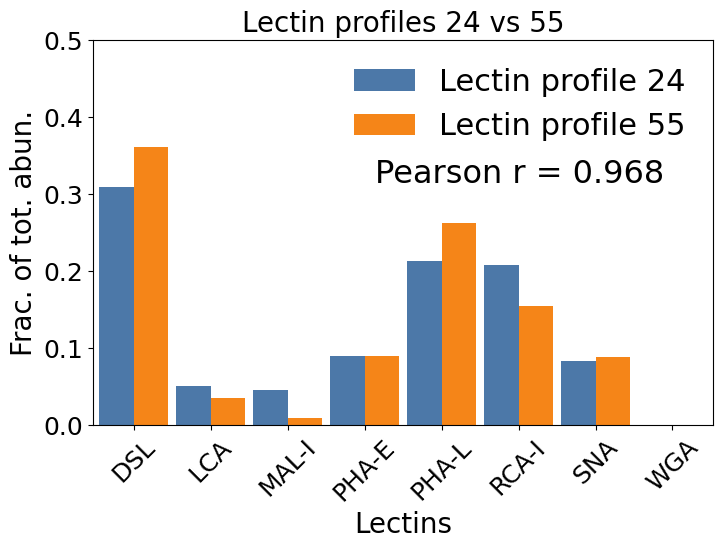

In [104]:
plot_lectin_profiles_grouped(sim_lp_df, 24, 55)